## 📝 Instrucciones

**Sistema de clasificación de imágenes**

El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

## Paso 1: Carga del conjunto de datos

El conjunto de datos se encuentra en este link. Descarga la carpeta y descomprime los archivos. Ahora tendrás una carpeta con el dataset y una carpeta llamada train que contiene más de 25.000 archivos de imagen (formato .jpg) de perros y gatos. Las fotos están etiquetadas por su nombre de archivo, con la palabra dog o cat.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image

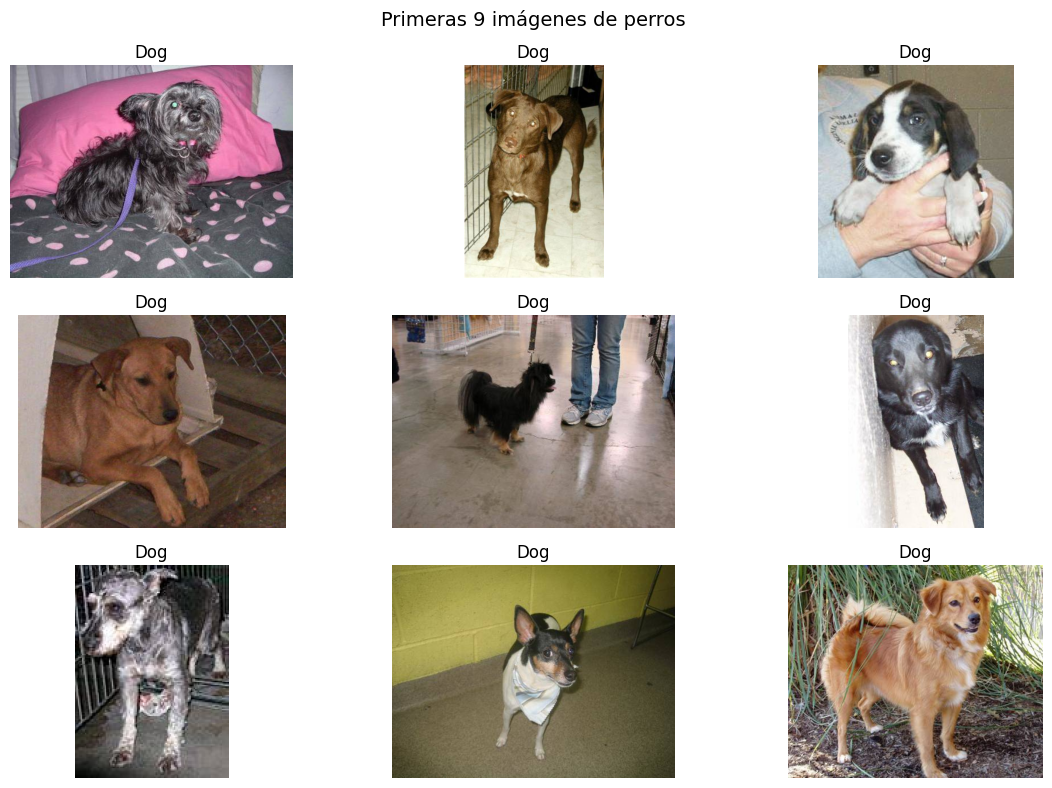

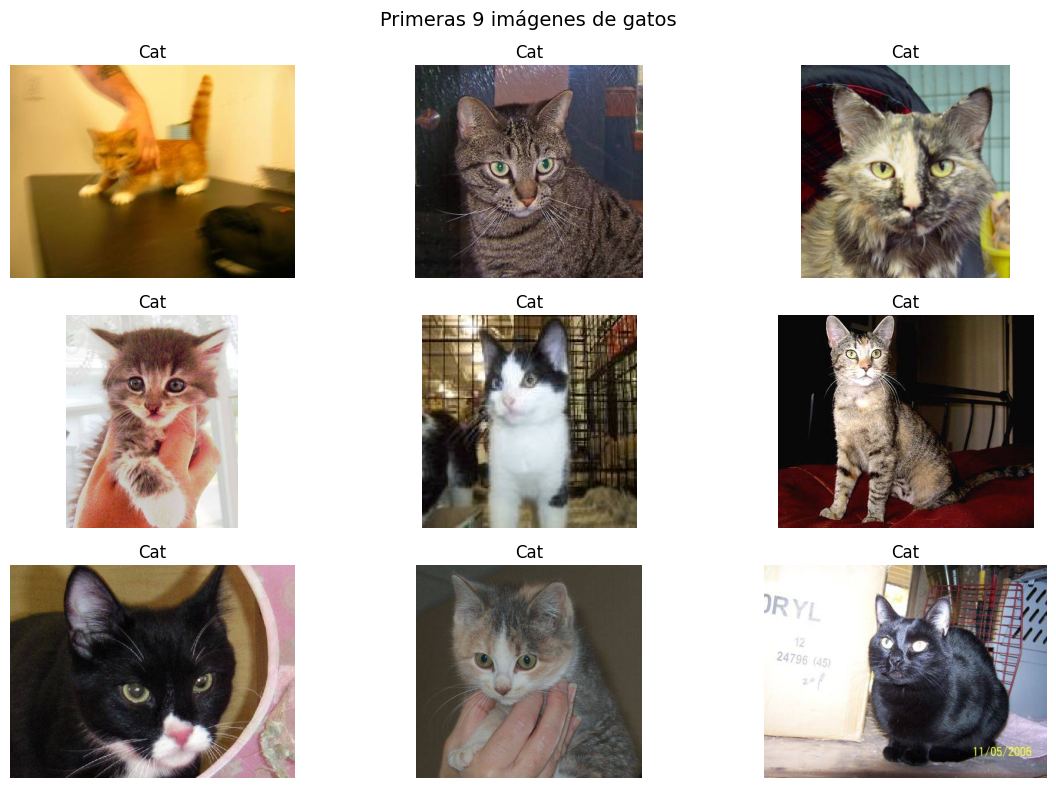

In [5]:

data_dir = os.path.join("..", "data", "raw", "dogs-vs-cats", "train")

# Filtrar imágenes de perros y gatos por nombre de archivo
all_files = os.listdir(data_dir)
dog_image_files = sorted([f for f in all_files if f.startswith("dog")])
cat_image_files = sorted([f for f in all_files if f.startswith("cat")])

# Función auxiliar para cargar imágenes
def load_images(file_list, folder, n=9):
    images = []
    for i in range(n):
        img_path = os.path.join(folder, file_list[i])
        img = image.load_img(img_path)
        img_array = image.img_to_array(img)
        img_array /= 255.0
        images.append(img_array)
    return images

# Cargar primeras 9 de cada clase
dog_images = load_images(dog_image_files, data_dir)
cat_images = load_images(cat_image_files, data_dir)

# Mostrar perros
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog')
    plt.axis('off')
plt.suptitle('Primeras 9 imágenes de perros', fontsize=14)
plt.tight_layout()
plt.show()

# Mostrar gatos
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cat_images[i])
    plt.title('Cat')
    plt.axis('off')
plt.suptitle('Primeras 9 imágenes de gatos', fontsize=14)
plt.tight_layout()
plt.show()

## Paso 2: Visualiza la información de entrada

El primer paso cuando nos enfrentamos a un problema de clasificación de imágenes es obtener toda la información posible a través de ellas. Por lo tanto, carga e imprime las primeras nueve fotos de perros en una sola figura. Repite lo mismo para los gatos. Puedes ver que las fotos son a color y tienen diferentes formas y tamaños.

Esta variedad de tamaños y formatos debe solucionarse antes de entrenar el modelo. Asegúrate de que todas tengan un tamaño fijo de 200x200 píxeles.

Como podrás ver, son una gran cantidad de imágenes, asegúrate de seguir las siguientes normas:

>1. Si tienes más de 12 gigabytes de RAM, usa la API de procesamiento de imágenes de Keras para cargar las 25.000 fotos en el conjunto de datos de entrenamiento y remodelarlas a fotos cuadradas de 200×200 píxeles. La etiqueta también debe determinarse para cada foto en función de los nombres de archivo. Se debe guardar una tupla de fotos y etiquetas._

>2. Si no tienes más de 12 gigabytes de RAM, carga las imágenes progresivamente usando la clase Keras ImageDataGenerator y la función flow_from_directory(). Esto será más lento de ejecutar, pero se ejecutará en hardware de menor capacidad. Esta función prefiere que los datos se dividan en directorios train y test separados, y debajo de cada directorio para tener un subdirectorio para cada clase.
    
Una vez tengas todas las imágenes procesadas, crea un objeto ImageDataGenerator para datos de entrenamiento y prueba. Luego pasa la carpeta que tiene datos de entrenamiento al objeto trdata y, de manera similar, pasa la carpeta que tiene datos de prueba al objeto tsdata. De esta forma, se etiquetarán las imágenes automáticamente y estará todo listo para entrar a la red.

In [7]:
from keras.utils import load_img, img_to_array
from concurrent.futures import ThreadPoolExecutor
import threading

IMG_SIZE = (200, 200)
raw_dir = os.path.join("..", "data", "raw", "dogs-vs-cats", "train")

all_files = sorted([f for f in os.listdir(raw_dir) if f.endswith(".jpg")])

def load_image(fname):
    label = 1 if fname.startswith("dog") else 0
    img = load_img(os.path.join(raw_dir, fname), target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0
    return img_array, label

# Ajusta workers según tus núcleos (prueba con 8, 12 o 16)
NUM_WORKERS = 8

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    results = list(executor.map(load_image, all_files))

photos, labels = zip(*results)
photos = np.array(photos)
labels = np.array(labels)
dataset = (photos, labels)

print(f"Fotos: {photos.shape}")
print(f"Etiquetas: {labels.shape}")
print(f"Perros: {labels.sum()} | Gatos: {(labels==0).sum()}")

Fotos: (25000, 200, 200, 3)
Etiquetas: (25000,)
Perros: 12500 | Gatos: 12500


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    photos, labels, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# Generadores
train_datagen = ImageDataGenerator()
test_datagen  = ImageDataGenerator()

trdata = train_datagen.flow(X_train, y_train, batch_size=32)
tsdata = test_datagen.flow(X_test, y_test, batch_size=32)

print("✅ Generadores listos")

Train: (20000, 200, 200, 3) | Test: (5000, 200, 200, 3)
✅ Generadores listos


## Paso 3: Construye una RNA

Cualquier clasificador que se ajuste a este problema tendrá que ser robusto porque algunas imágenes muestran al gato o al perro en una esquina o tal vez a 2 gatos o perros en la misma foto. Si has podido investigar algunas de las implementaciones de los ganadores de otras competiciones también relacionadas con imágenes, verás que VGG16 es una arquitectura de CNN utilizada para ganar la competencia de Kaggle ILSVR (Imagenet) en 2014. Se considera una de las arquitecturas de modelos de visión con mejores resultados hasta la fecha.

**Utiliza la siguiente arquitectura de prueba:**

    model = Sequential()
    model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
    model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
    model.add(Flatten())
    model.add(Dense(units = 4096,activation = "relu"))
    model.add(Dense(units = 4096,activation = "relu"))
    model.add(Dense(units = 2, activation = "softmax"))

El código anterior aplica convoluciones a los datos (capas Conv2D y MaxPool2D) y después aplica capas densas (capas Dense) para el procesamiento de los valores numéricos obtenidos tras las convoluciones.

A continuación añade los elementos restantes para conformar el modelo, entrénalo y mide su rendimiento.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.optimizers import Adam

#Modificación a la estructura ofrecida en el ejercicio porque el shape de mi dataset es (200, 200, 3) y no (224, 224, 3)
model = Sequential()
model.add(Conv2D(input_shape=(200, 200, 3), filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=2, activation="softmax"))

# Compilar
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()

c:\Users\ekbal\Documents\GitHub\ekbalam11-machine-learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,005,762 (408.19 MB)

 Trainable params: 107,005,762 (408.19 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
import os

# One-hot encoding
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat  = to_categorical(y_test,  num_classes=2)

# Recrear generadores
trdata = train_datagen.flow(X_train, y_train_cat, batch_size=32)
tsdata = test_datagen.flow(X_test,  y_test_cat,  batch_size=32)

# Callbacks
os.makedirs("../models", exist_ok=True)
checkpoint = ModelCheckpoint(
    "../models/vgg16_best.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="auto"
)
early = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=1,
    mode="auto"
    
)

# Entrenar
hist = model.fit(
    trdata,
    epochs=20,
    validation_data=tsdata,
    callbacks=[checkpoint, early]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4940 - loss: 0.6933
Epoch 1: val_accuracy improved from None to 0.49700, saving model to ../models/vgg16_best.keras

Epoch 1: finished saving model to ../models/vgg16_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 2554s 4s/step - accuracy: 0.4974 - loss: 0.6932 - val_accuracy: 0.4970 - val_loss: 0.6932
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4955 - loss: 0.6932
Epoch 2: val_accuracy did not improve from 0.49700
625/625 ━━━━━━━━━━━━━━━━━━━━ 2497s 4s/step - accuracy: 0.4963 - loss: 0.6932 - val_accuracy: 0.4970 - val_loss: 0.6932
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5012 - loss: 0.6932
Epoch 3: val_accuracy did not improve from 0.49700
625/625 ━━━━━━━━━━━━━━━━━━━━ 2497s 4s/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.4970 - val_loss: 0.6932
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5057 - loss: 0.6932
Epoch 4: val_accuracy improved from 0.49700

KeyboardInterrupt: 

Durante el entrenamiento se observó que el modelo tampoco estaba aprendiendo correctamente: la accuracy se mantuvo en ~50% y la loss se quedó fija en 0.6932 (equivalente a ln(2)), que es el valor exacto de un modelo que predice al azar en un problema binario. Esto indica que el modelo estaba atascado en un punto muerto sin capacidad de converger.
El entrenamiento fue detenido manualmente tras 6 épocas al confirmar que no había mejora. La causa principal es un learning rate demasiado alto (0.001), que provoca que los pesos oscilen sin encontrar dirección de aprendizaje. Para corregirlo se reentrenará el modelo con un learning rate de 0.0001, diez veces menor, lo que permite actualizaciones más suaves y estables que favorecen la convergencia.

En el archivo _solution_ se muestra una val_accuracy de 1.0, que parece un resultado perfecto pero en realidad es un error: el modelo estaba validando contra imágenes de una sola clase, por lo que acertaba siempre de forma artificial. En esta implementación se corrige esto haciendo un split 80/20 real sobre el dataset completo.

### Corrección del modelo

In [14]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from keras.optimizers import Adam

model = Sequential()
model.add(Conv2D(input_shape=(200, 200, 3), filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=2, activation="softmax"))

# Learning rate corregido
model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=Adam(learning_rate=0.0001),
    metrics=["accuracy"]
)

print("✅ Modelo listo con lr=0.0001")

✅ Modelo listo con lr=0.0001


In [15]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "../models/vgg16_best.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="auto"
)
early = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=1,
    mode="auto"
)

hist = model.fit(
    trdata,
    epochs=20,
    validation_data=tsdata,
    callbacks=[checkpoint, early]
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4954 - loss: 0.6936
Epoch 1: val_accuracy improved from None to 0.49700, saving model to ../models/vgg16_best.keras

Epoch 1: finished saving model to ../models/vgg16_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 2632s 4s/step - accuracy: 0.4972 - loss: 0.6933 - val_accuracy: 0.4970 - val_loss: 0.6932
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4992 - loss: 0.6932
Epoch 2: val_accuracy improved from 0.49700 to 0.50300, saving model to ../models/vgg16_best.keras

Epoch 2: finished saving model to ../models/vgg16_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 2558s 4s/step - accuracy: 0.4992 - loss: 0.6932 - val_accuracy: 0.5030 - val_loss: 0.6931
Epoch 3/20
110/625 ━━━━━━━━━━━━━━━━━━━━ 34:26 4s/step - accuracy: 0.5020 - loss: 0.6931

KeyboardInterrupt: 

Parece que el proyecto no es viable en local porque no existe soporte aun de Tensorflow para la GPU que tengo (NVIDIA GeForce RTX 5070 Laptop GPU), por lo tanto continúo el ejercicio en Google Colab a partir de aquí...

## Paso 4: Optimiza el modelo anterior

Importa el método ModelCheckpoint y EarlyStopping de Keras. Crea un objeto de ambos y pásalo como funciones callback a fit_generator.

Carga el mejor modelo de los anteriores y utiliza el conjunto de test para hacer predicciones.

## Paso 5: Guarda el modelo

Almacena el modelo en la carpeta correspondiente.